# Libraries Imports


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


file_path = '/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv'
df = pd.read_csv(file_path)
# Download necessary NLTK resources silently
nltk.download('stopwords', quiet=True)
print("All libraries imported successfully!")

All libraries imported successfully!


 # Data Reading & Exploration (EDA)

--- Dataset General Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None

Total Dataset Shape: (53043, 3)

--- Initial Class Distribution ---
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


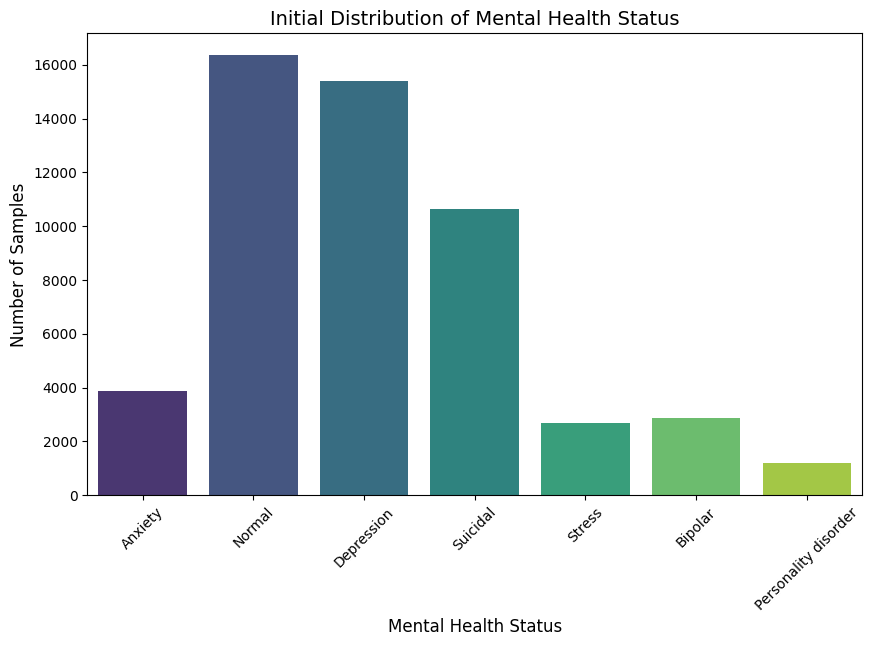

In [2]:
print("--- Dataset General Information ---")
print(df.info())
print(f"\nTotal Dataset Shape: {df.shape}")

print("\n--- Initial Class Distribution ---")
print(df['status'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='status', data=df, palette='viridis', hue='status', legend=False)
plt.title('Initial Distribution of Mental Health Status', fontsize=14)
plt.xlabel('Mental Health Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Handling Missing Values & Unbalanced Data

In [3]:
# 1. Remove rows with missing values (NaN)
initial_len = len(df)
df = df.dropna(subset=['statement', 'status']).reset_index(drop=True)
print(f"Removed {initial_len - len(df)} missing rows. Current size: {len(df)}")

# 2. Handle Imbalanced Data using DataFrame Oversampling
# We will upsample minority classes to match the size of the majority class
majority_class_size = df['status'].value_counts().max()
balanced_dfs = []

for class_label in df['status'].unique():
    class_subset = df[df['status'] == class_label]
    
    if len(class_subset) < majority_class_size:
        # Upsample minority class
        upsampled_subset = resample(
            class_subset, 
            replace=True,                  # Sample with replacement
            n_samples=majority_class_size, # Match majority class size
            random_state=42
        )
        balanced_dfs.append(upsampled_subset)
    else:
        balanced_dfs.append(class_subset)

# Combine and shuffle the balanced dataset
df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- Class Distribution AFTER Balancing ---")
print(df_balanced['status'].value_counts())

Removed 362 missing rows. Current size: 52681

--- Class Distribution AFTER Balancing ---
status
Personality disorder    16343
Bipolar                 16343
Normal                  16343
Depression              16343
Stress                  16343
Suicidal                16343
Anxiety                 16343
Name: count, dtype: int64


# Text Preprocessing

In [4]:
negations = {'not', 'no', 'nor', 'against', 'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}
SMART_STOPWORDS = set(stopwords.words('english')) - negations

def preprocess_text(text):
    """
    Comprehensive text cleaning: lowercasing, removing URLs, 
    stripping punctuation, and filtering specific stopwords.
    """
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove links
    text = re.sub(r'[^\w\s]', ' ', text)              # Remove punctuation
    
    words = text.split()
    cleaned_words = [word for word in words if word not in SMART_STOPWORDS]
    return " ".join(cleaned_words)

# --- Before Preview ---
print("--- Before Preprocessing (First 3 statements) ---")
for i in range(3):
    print(f"{i+1}. {df_balanced['statement'].iloc[i]}")

# Apply preprocessing
print("\nApplying text preprocessing... (This may take a moment)")
df_balanced['cleaned_text'] = df_balanced['statement'].apply(preprocess_text)

# --- After Preview ---
print("\n--- After Preprocessing (First 3 statements) ---")
for i in range(3):
    print(f"{i+1}. {df_balanced['cleaned_text'].iloc[i]}")

print("\nPreprocessing completed successfully!")

--- Before Preprocessing (First 3 statements) ---
1. Why am i so weird and how to get better interacting with people? Context- when “normal” people interact with each other they speak and converse like they know eachother beforehand when they dont. But im always quiet and just silently looking at them? And like i know they notice it and sometimes they dont even want to interact because im so silent? 

Its like really hard to interact with when it’s about personal relationship. But when i have appointments its easier?

(Extrovert/ normal idk What to Call it)
2. Therapist is trying a new CBT thing with me So my therapist has been saying I'm improving after a big setback. She wants me to try this thing I'll call the thought tree. When you get triggered you write what in that moment hurt you as the trunk. You then make limbs by writing what you thought when it happened. Kinda like the A,B,C chart. It all accumulates to the a big covering with your feeling as the leaves. Anyone else do this

# Feature Extraction & Data Splitting

In [5]:
X = df_balanced['cleaned_text']
y = df_balanced['status']

# Split the dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize TF-IDF Vectorizer with N-grams to capture word context
# We use top 10,000 features and unigrams + bigrams
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit and transform the training data, then transform the test data
print("Extracting features using TF-IDF...")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Training Features Shape: {X_train_vec.shape}")
print(f"Testing Features Shape: {X_test_vec.shape}")

Extracting features using TF-IDF...
Training Features Shape: (91520, 10000)
Testing Features Shape: (22881, 10000)


# Model Construction & Training


In [6]:
# Constructing a Logistic Regression Model
# It is highly efficient for text classification with sparse TF-IDF matrices
model = LogisticRegression(
    max_iter=2000,       # High iteration limit to ensure convergence
    random_state=42,
    n_jobs=-1            # Utilize all CPU cores for faster training
)

print("Training the Machine Learning model...")
# Train the model on the vectorized training data
model.fit(X_train_vec, y_train)
print("Model training completed!")

Training the Machine Learning model...
Model training completed!


# Final Model Evaluation

In [7]:
# Generate predictions on the unseen test set
y_predictions = model.predict(X_test_vec)

# Calculate overall accuracy
final_accuracy = accuracy_score(y_test, y_predictions)
print(f"=== Final Model Accuracy: {final_accuracy * 100:.2f}% ===\n")

# Generate a detailed classification report
print("Detailed Performance Report (Precision, Recall, F1-Score):")
print("-" * 60)
report = classification_report(y_test, y_predictions)
print(report)

=== Final Model Accuracy: 89.13% ===

Detailed Performance Report (Precision, Recall, F1-Score):
------------------------------------------------------------
                      precision    recall  f1-score   support

             Anxiety       0.94      0.93      0.94      3268
             Bipolar       0.96      0.96      0.96      3268
          Depression       0.80      0.68      0.74      3269
              Normal       0.89      0.92      0.90      3269
Personality disorder       0.96      1.00      0.98      3269
              Stress       0.90      0.94      0.92      3269
            Suicidal       0.79      0.81      0.80      3269

            accuracy                           0.89     22881
           macro avg       0.89      0.89      0.89     22881
        weighted avg       0.89      0.89      0.89     22881



# ROC Curve Analysis (Multi-Class)

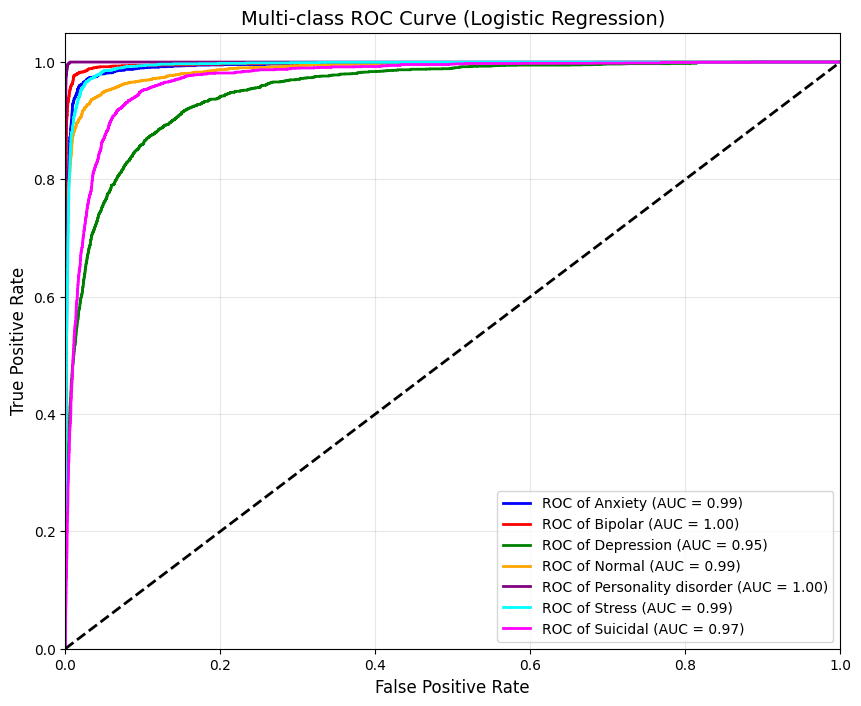

In [8]:
# 1. Binarize labels (One-vs-Rest approach for ML Multi-class)
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

# 2. Use predict_proba which is standard for Logistic Regression
y_score = model.predict_proba(X_test_vec)

# 3. Compute ROC curve and AUC for each mental health status
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC of {model.classes_[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve (Logistic Regression)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()